# A/B Test Analysis: Cookie Cats Gate Placement Experiment

**Dataset:** [Mobile Games A/B Testing with Cookie Cats](https://github.com/ryanschaub/Mobile-Games-A-B-Testing-with-Cookie-Cats) — 90,189 real players of the mobile puzzle game *Cookie Cats*, randomized into two versions of the game that place the first progression "gate" at either **level 30** (control) or **level 40** (treatment).

**Business question:** Does moving the gate later increase or decrease player retention?

**What this notebook covers (a full experimentation workflow, not just a t-test):**
1. Data loading & validation
2. Prospective **power analysis** — how large a sample is needed to detect a meaningful effect?
3. **Sample Ratio Mismatch (SRM)** check — a sanity check that randomization worked
4. **Two-proportion z-tests** on 1-day and 7-day retention, with 95% confidence intervals on the lift
5. A secondary continuous-metric check (game rounds played) using Welch's t-test + bootstrap CI
6. Visualization and a business recommendation



In [1]:
import sys
sys.path.insert(0, 'src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from experiment_framework import (
    required_sample_size, srm_check, two_proportion_ztest, welch_ttest_with_bootstrap_ci
)

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load and validate the data

In [2]:
df = pd.read_csv('data/cookie_cats.csv')
print(df.shape)
df.head()

(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
# Data quality checks
print('Nulls:\n', df.isnull().sum())
print('Duplicate userids:', df['userid'].duplicated().sum())
print('Groups:', df['version'].value_counts().to_dict())

Nulls:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
Duplicate userids: 0
Groups: {'gate_40': 45489, 'gate_30': 44700}


## 2. Power analysis (the planning-stage question)

Before trusting any A/B test result, we should ask: *was the sample even large enough to detect an effect we'd care about?* Here we compute the sample size required to detect a **1 percentage point absolute change** in 1-day retention, at the conventional alpha=0.05 and power=0.80, using Cohen's h (the variance-stabilizing effect size for proportions).

In [4]:
baseline_r1 = df.loc[df.version == 'gate_30', 'retention_1'].mean()
power_result = required_sample_size(baseline_rate=baseline_r1, mde_abs=0.01, alpha=0.05, power=0.80)
power_result

{'baseline_rate': np.float64(0.4481879194630872),
 'target_rate': np.float64(0.45818791946308723),
 'mde_abs': 0.01,
 'cohens_h': 0.0200885820718002,
 'alpha': 0.05,
 'power': 0.8,
 'n_per_group': 38899,
 'n_treatment': 38899,
 'n_total': 77798}

In [5]:
print(f"Required total sample size: {power_result['n_total']:,}")
print(f"Actual sample collected:    {len(df):,}")
print('=> Sufficiently powered' if len(df) >= power_result['n_total'] else '=> Underpowered')

Required total sample size: 77,798
Actual sample collected:    90,189
=> Sufficiently powered


## 3. Sample Ratio Mismatch (SRM) check

A chi-square goodness-of-fit test on the observed group sizes vs. the expected 50/50 split. We use a strict p < 0.0001 threshold (the standard used by large experimentation platforms), since a plain p < 0.05 test flags most large-sample experiments as "broken" purely from noise.

In [6]:
n_control = (df.version == 'gate_30').sum()
n_treatment = (df.version == 'gate_40').sum()
srm = srm_check(n_control, n_treatment)
srm

{'n_control': np.int64(44700),
 'n_treatment': np.int64(45489),
 'observed_ratio': np.float64(0.49562585237667567),
 'expected_ratio': 0.5,
 'chi2': np.float64(6.9024049496058275),
 'p_value': np.float64(0.008607987810836262),
 'srm_alpha': 0.0001,
 'srm_detected': np.False_}

## 4. Primary metric: 1-day retention

Two-proportion z-test comparing `retention_1` between `gate_30` (control) and `gate_40` (treatment).

In [7]:
res_r1 = two_proportion_ztest(
    successes_control=df.loc[df.version=='gate_30','retention_1'].sum(), n_control=n_control,
    successes_treatment=df.loc[df.version=='gate_40','retention_1'].sum(), n_treatment=n_treatment,
    metric_name='1-day retention'
)
print(res_r1.summary())

[1-day retention] control=44.8188% (n=44,700)  treatment=44.2283% (n=45,489)
  abs lift = -0.5905%  95% CI [-1.2392%, +0.0582%]
  rel lift = -1.32%  95% CI [-2.77%, +0.13%]
  z = -1.784   p = 0.07441   Cohen's h = -0.0119   significant at alpha=0.05: no


## 5. Secondary metric: 7-day retention

In [8]:
res_r7 = two_proportion_ztest(
    successes_control=df.loc[df.version=='gate_30','retention_7'].sum(), n_control=n_control,
    successes_treatment=df.loc[df.version=='gate_40','retention_7'].sum(), n_treatment=n_treatment,
    metric_name='7-day retention'
)
print(res_r7.summary())

[7-day retention] control=19.0201% (n=44,700)  treatment=18.2000% (n=45,489)
  abs lift = -0.8201%  95% CI [-1.3282%, -0.3121%]
  rel lift = -4.31%  95% CI [-6.98%, -1.64%]
  z = -3.164   p = 0.001554   Cohen's h = -0.0211   significant at alpha=0.05: YES


## 6. Secondary continuous metric: game rounds played

The raw `sum_gamerounds` column has an extreme outlier (one player logged ~49,854 rounds in 14 days), so we trim the top 0.1% before comparing means with Welch's t-test, and use a percentile bootstrap for a distribution-free confidence interval on the difference in means.

In [9]:
rounds = df['sum_gamerounds']
cutoff = rounds.quantile(0.999)
print(f"Trimming values above {cutoff:.0f} rounds ({(rounds>cutoff).sum()} players)")
df_clean = df[rounds <= cutoff]

control_rounds = df_clean.loc[df_clean.version=='gate_30','sum_gamerounds'].values
treatment_rounds = df_clean.loc[df_clean.version=='gate_40','sum_gamerounds'].values
res_rounds = welch_ttest_with_bootstrap_ci(control_rounds, treatment_rounds, metric_name='Game rounds played')
res_rounds

Trimming values above 1074 rounds (91 players)


{'metric': 'Game rounds played',
 'mean_control': np.float64(50.0920978974003),
 'mean_treatment': np.float64(49.8099209929796),
 'median_control': np.float64(17.0),
 'median_treatment': np.float64(16.0),
 'diff_means': np.float64(-0.28217690442070165),
 't_stat': np.float64(-0.4583133178218845),
 'p_value': np.float64(0.6467284631928546),
 'bootstrap_ci_low': np.float64(-1.521047878692026),
 'bootstrap_ci_high': np.float64(0.9342205766262556),
 'significant': np.False_}

## 7. Visualizations

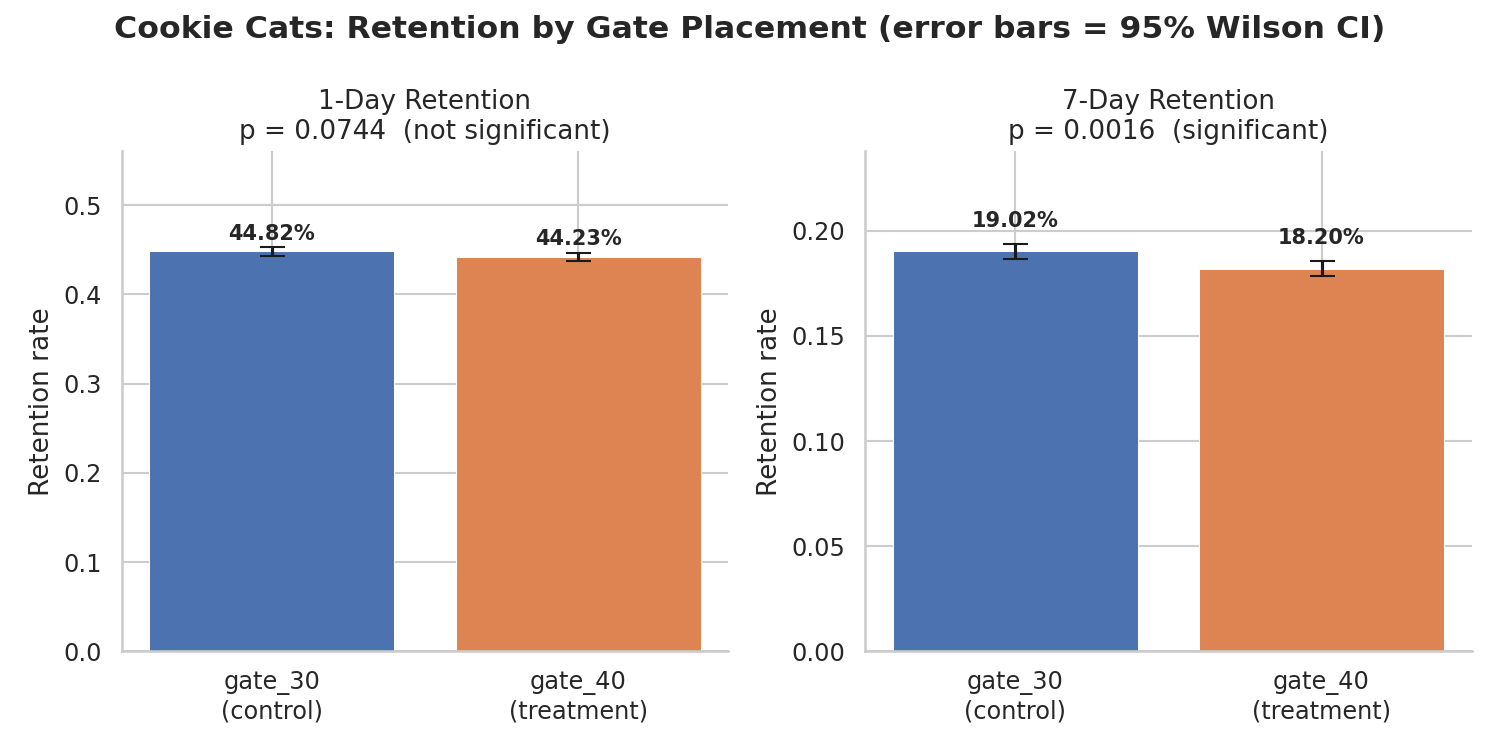

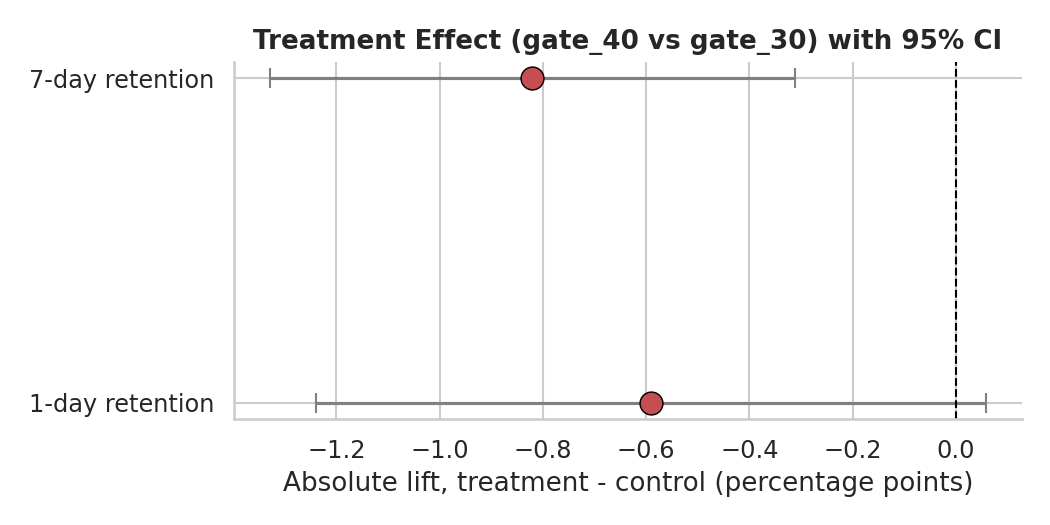

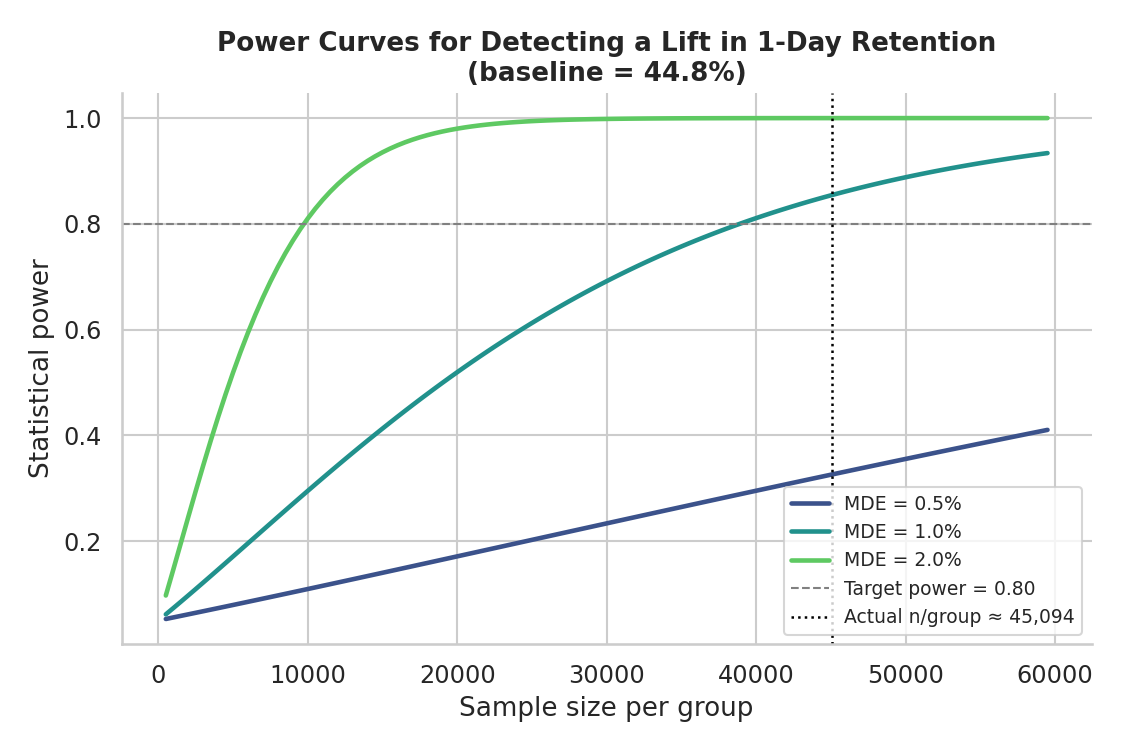

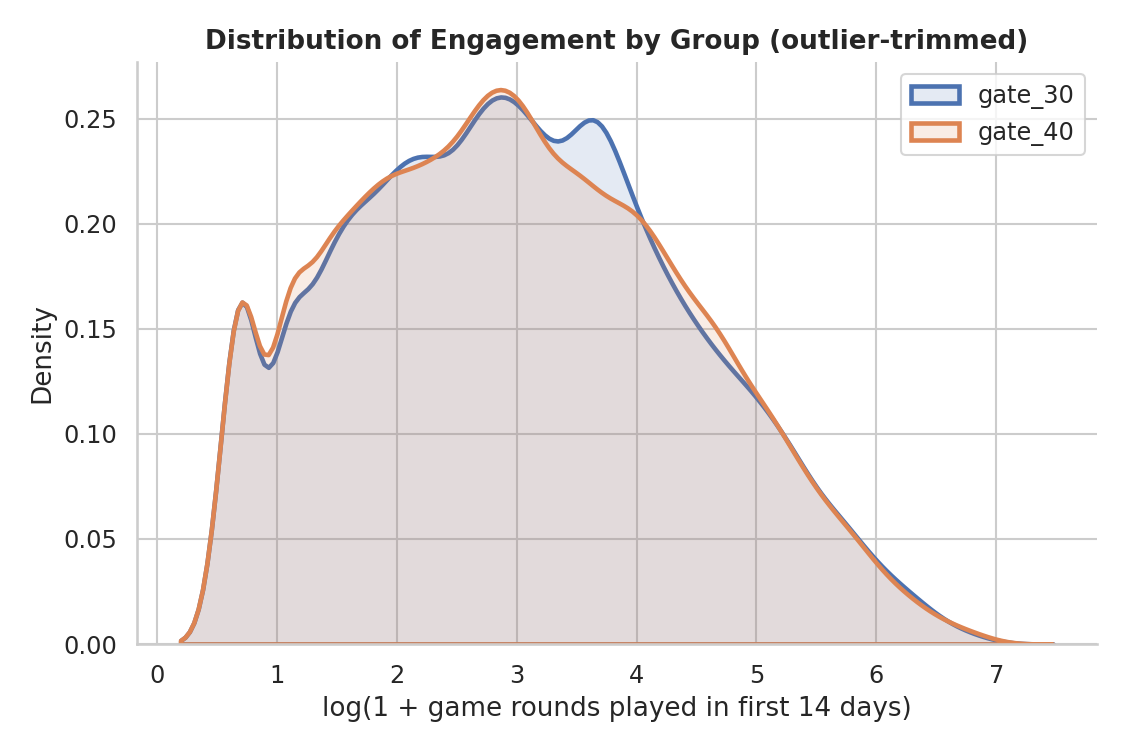

In [10]:
from IPython.display import Image, display
for f in ['fig1_retention_by_group.png', 'fig2_lift_forest_plot.png',
          'fig3_power_curve.png', 'fig4_gamerounds_distribution.png']:
    display(Image(filename=f'results/{f}'))

## 8. Results summary

| Metric | Control | Treatment | Abs. Lift | 95% CI | Rel. Lift | p-value | Significant (a=0.05)? |
|---|---|---|---|---|---|---|---|
| 1-day retention | 44.82% | 44.23% | -0.59pp | [-1.24pp, +0.06pp] | -1.32% | 0.074 | No |
| 7-day retention | 19.02% | 18.20% | -0.82pp | [-1.33pp, -0.31pp] | -4.31% | 0.0016 | **Yes** |
| Game rounds played | 50.09 | 49.81 | -0.28 | [-1.52, +0.93] | - | 0.647 | No |

## 9. Conclusion & recommendation

Both retention metrics point in the same (negative) direction for the treatment (`gate_40`), and the effect reaches statistical significance on the more decision-relevant **7-day retention** metric (a 4.3% relative drop, p = 0.0016). 1-day retention shows the same direction but is not statistically significant on its own -- its 95% CI still contains a small positive effect.

Game engagement (rounds played) is statistically indistinguishable between groups, which tells us the retention drop isn't from players simply playing less before churning -- they are churning outright at a higher rate under the treatment.

**Recommendation: do not ship `gate_40`.** Keep the gate at level 30. Moving the progression gate later removes an early pacing/monetization checkpoint, but the evidence indicates it costs the game player retention -- the metric that most directly drives long-term value for a free-to-play title. A larger follow-up sample (see the power analysis in Section 2) could sharpen the 1-day retention estimate, but current evidence does not support the change.

---
*Full source code: `src/experiment_framework.py` (reusable statistical toolkit) and `src/run_analysis.py` (analysis pipeline). Run `python src/run_analysis.py` to reproduce all figures and `results/metrics.json`.*